# A. Table of content:

- [B. Instructions:](#B-Instructions:)    
- [C. Import, functions & data load:](#C.-Import,-functions-&-data-load:)    
- [1. Data pre-processing:](#1.-Data-pre-processing:)  
    - [1.1. Dataset inspection:](#1.1.-Dataset-inspection:)   
    - [1.2. Feature engineering:](#1.2.-Feature-engineering:)  
        - [1.2.1. General:](#1.2.1.-General:)  
        - [1.2.2. Preparation for machine learning modeling:](#1.2.2.-Preparation-for-machine-learning-modeling:)  
        - [1.2.3. Preparation for deep learning modeling:](#1.2.3.-Preparation-for-deep-learning-modeling:)   
        - [1.2.4. Preparation for transformer modeling:](#1.2.4.-Preparation-for-transformer-modeling:)    
- [2. Modeling:](#2.-Modeling:)  
    - [2.1. Machine learning modeling - Random Forest:](#2.1.-Machine-learning-modeling---Random-Forest:)  
        - [2.1.1. Bayesian optimization:](#2.1.1.-Bayesian-optimization:)  
        - [2.1.2. Random Forest modeling:](#2.1.2.-Random-Forest-modeling:)
    - [2.2. Machine learning modeling - Logistic Regression:](#2.2.-Machine-learning-modeling---Logistic-Regression:)  
        - [2.2.1. Bayesian optimization:](#2.2.1.-Bayesian-optimization:)  
        - [2.2.2. Logistic Regression modeling:](#2.2.2.-Logistic-Regression-modeling:)  
    - [2.3. Deep learning modeling:](#2.3.-Deep-learning-modeling:)   
    - [2.4. Transformer modeling:](#2.4.-Transformer-modeling:)
    - [2.5. Performance metrics, model selection & overall conclusion:](#2.5.-Performance-metrics,-model-selection-&-overall-conclusion:)
        - [2.5.1. Machine learning modeling - Random Forest performance metrics:](#2.5.1.-Machine-learning-modeling---Random-Forest-performance-metrics:)
        - [2.5.2. Machine learning modeling - Logistic Regression performance metrics:](#2.5.2.-Machine-learning-modeling---Logistic-Regression-performance-metrics:)
        - [2.5.3. Deep learning performance metrics:](#2.5.3.-Deep-learning-performance-metrics:)
        - [2.5.4. Transformer performance metrics:](#2.5.4.-Transformer-performance-metrics:)
        - [2.5.5. Model selection & overall conclusion:](#2.5.5.-Model-selection-&-overall-conclusion:)  

# B. Instructions:

In [1]:
from IPython.display import IFrame

In [2]:
instructions_path = r"..\references\4_5_PreProcessing_Modeling\1585013368_Capstone_Three_Steps_4-5_-_Google_Docs.pdf"

In [3]:
IFrame(instructions_path, width=800, height=600)

# C. Import, functions & data load:

**IMPORT:**

In [72]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier
from bayes_opt import BayesianOptimization
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
# !pip install tensorflow
import tensorflow as tf
import keras
from keras.metrics import AUC
from keras import layers, models, regularizers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, f1_score, roc_auc_score
# from keras.regularizers import l2
from sklearn.linear_model import LogisticRegression
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from scipy.special import softmax
import torch
%pip install -q ipywidgets
import transformers
from transformers.utils.logging import set_verbosity_info

Note: you may need to restart the kernel to use updated packages.


**CONDA ENVIRONMENT EXPORT:**

In [5]:
!conda env export -n nlpenv --no-builds > CapstoneThree_Preprocessing_Modeling_env.yml
!dir CapstoneThree_Preprocessing_Modeling_env.yml

 Volume in drive C is OS
 Volume Serial Number is 3CC3-E130

 Directory of C:\Users\Benoit Loze\Desktop\SPRINGBOARD\_CURSUS\34_Deep_Learning\34.4_Capstone_Three\34.4_capstonethree_fakenewsdetection\notebooks

08/21/2025  10:08 PM             6,367 CapstoneThree_Preprocessing_Modeling_env.yml
               1 File(s)          6,367 bytes
               0 Dir(s)  329,906,692,096 bytes free


**FUNCTIONS**

In [6]:
def model_performance_metrics(model, research_method, y_test, y_pred):
    """
    Compute, print and return the F1, Precision, Recall scores
    Display the classification report and the confusion matrix
    """

    # compute metrics:
    f1_score_model = f1_score(y_test, y_pred, average="macro")
    precision_model = precision_score(y_test, y_pred, average="macro")
    recall_model = recall_score(y_test, y_pred, average="macro")
    classification_report_model = classification_report(y_test, y_pred)
    cm_model = confusion_matrix(y_test, y_pred)

    # print metrics:
    print(f"{model}, {research_method}, F1 score: {f1_score_model}.")
    print(f"{model}, {research_method}, Precision score: {precision_model}.")
    print(f"{model}, {research_method}, Recall score: {recall_model}.")
    print(f"\n{model}, {research_method}, Classification Report:\n {classification_report_model}.")
    print()

    #display confusion matrix:
    cm_model_display = ConfusionMatrixDisplay(confusion_matrix=cm_model)
    cm_model_display.plot(cmap="Blues")
    plt.title(f"{model} - {research_method}, Confusion Matrix")
    plt.show()

    # returns metrics for logging or comparison:
    return {"f1":f1_score_model, "precision":precision_model, "recall":recall_model}

**DATA LOAD:**

In [7]:
dataset_path = r"..\data\processed\df_data_wrangling_eda.csv"

In [8]:
df = pd.read_csv(dataset_path)

In [9]:
raw_dataset_path = r"..\data\processed\df_title_text-label_original.csv"

In [10]:
df_raw = pd.read_csv(raw_dataset_path)

# 1. Data pre-processing:

## 1.1. Dataset inspection:

In [11]:
df.head()

,date,source,author,category,label,title_cleaned,text_cleaned
0,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final,tax development store agreement lawyer hear ou...
1,2022-05-25,Fox News,Joseph Hill,Politics,fake,offer resource great point,probably guess western likely investment consu...
2,2022-09-01,CNN,Julia Robinson,Business,fake,church carry,identify forward present success risk pull blo...
3,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,unit,phone item yard republican safe police identif...
4,2023-04-03,CNN,Austin Walker,Technology,fake,billion believe employee summer,wonder fact difficult course forget exactly pa...


In [12]:
df.shape

(20000, 7)

## 1.2. Feature engineering:

### 1.2.1. General:

**HIGH CARDINALITY FEATURES:**

The "date" and the "author" feature columns have a **very high cardinality**, which might not support he "label" classification.  
Therefore, their feature columns will be dropped from the dataset.  

In [13]:
df["date"].nunique()

1096

In [14]:
df["author"].nunique()

17052

In [15]:
df.drop(["date", "author"], axis=1, inplace=True)
df.head()

,source,category,label,title_cleaned,text_cleaned
0,NY Times,Politics,real,foreign democrat final,tax development store agreement lawyer hear ou...
1,Fox News,Politics,fake,offer resource great point,probably guess western likely investment consu...
2,CNN,Business,fake,church carry,identify forward present success risk pull blo...
3,Reuters,Science,fake,unit,phone item yard republican safe police identif...
4,CNN,Technology,fake,billion believe employee summer,wonder fact difficult course forget exactly pa...


**TARGET ONE-HOT ENCODING:**

In [16]:
df.columns

Index(['source', 'category', 'label', 'title_cleaned', 'text_cleaned'], dtype='object')

In [17]:
new_order = ["source", "category", "title_cleaned", "text_cleaned",
       "label_dummy", "label"]

In [18]:
df["label_dummy"] = pd.get_dummies(df["label"], drop_first=True).astype(int)
df = df[new_order]
df.head(10)

,source,category,title_cleaned,text_cleaned,label_dummy,label
0,NY Times,Politics,foreign democrat final,tax development store agreement lawyer hear ou...,1,real
1,Fox News,Politics,offer resource great point,probably guess western likely investment consu...,0,fake
2,CNN,Business,church carry,identify forward present success risk pull blo...,0,fake
3,Reuters,Science,unit,phone item yard republican safe police identif...,0,fake
4,CNN,Technology,billion believe employee summer,wonder fact difficult course forget exactly pa...,0,fake
5,Reuters,Health,method purpose mission approach professor short,affect bill kind project turn official pull af...,1,real
6,CNN,Business,laugh member step,newspaper establish fall president response mo...,0,fake
7,NY Times,Sports,center measure difference dark,ready movement bed increase history truth miss...,0,fake
8,Fox News,Entertainment,moment affect difference,officer mention dream fill late foot suffer dr...,0,fake
9,Daily News,Health,reason physical contain total decision,choose treat political minute set true thousan...,1,real


**CATEGORICAL FEATURES:**

Concerning the **"source"** and the **"category** features and to perhaps **confirm or not the "exploratory data analysis" stage discoveries**, **"ANOVA"** will be used to determine if those features effectively support the classification.  
As **"ANOVA"** expects **numerical inputs**, both **"author"** and **"category"** features will be **one-hot encoded**. As their unique values are below the 10-value threshold, one-hot encoding is preferred to label encoding, which besides could induce a wrong ordering perturbing "ANOVA" analysis.  

In [19]:
df["source"].nunique()

8

In [20]:
df["category"].nunique()

7

In [21]:
df_cat_dummies = pd.get_dummies(df, columns=["source", "category"], drop_first=True, dtype=int)
# df_cat_dummies[dummies_cols] = df_cat_dummies[dummies_cols].astype(int)
df_cat_dummies.head()

,title_cleaned,text_cleaned,label_dummy,label,source_CNN,source_Daily News,source_Fox News,source_Global Times,source_NY Times,source_Reuters,source_The Guardian,category_Entertainment,category_Health,category_Politics,category_Science,category_Sports,category_Technology
0,foreign democrat final,tax development store agreement lawyer hear ou...,1,real,0,0,0,0,1,0,0,0,0,1,0,0,0
1,offer resource great point,probably guess western likely investment consu...,0,fake,0,0,1,0,0,0,0,0,0,1,0,0,0
2,church carry,identify forward present success risk pull blo...,0,fake,1,0,0,0,0,0,0,0,0,0,0,0,0
3,unit,phone item yard republican safe police identif...,0,fake,0,0,0,0,0,1,0,0,0,0,1,0,0
4,billion believe employee summer,wonder fact difficult course forget exactly pa...,0,fake,1,0,0,0,0,0,0,0,0,0,0,0,1


In [22]:
dummies_cols = [c for c in df_cat_dummies.columns if "source_" in c or "category_" in c]
dummies_cols

['source_CNN',
 'source_Daily News',
 'source_Fox News',
 'source_Global Times',
 'source_NY Times',
 'source_Reuters',
 'source_The Guardian',
 'category_Entertainment',
 'category_Health',
 'category_Politics',
 'category_Science',
 'category_Sports',
 'category_Technology']

In [23]:
# ANOVA analysis:
y = df_cat_dummies["label_dummy"]
X = df_cat_dummies[dummies_cols]

f_values, p_values = f_classif(X, y)

df_anova = pd.DataFrame({
    "Feature": X.columns,
    "F_value": f_values,
    "p_value": p_values
}).sort_values("p_value")

df_anova

,Feature,F_value,p_value
4,source_NY Times,1.431921,0.231465
10,category_Science,1.153734,0.282782
12,category_Technology,1.019139,0.312735
8,category_Health,0.263433,0.607777
5,source_Reuters,0.216087,0.642043
2,source_Fox News,0.206846,0.649256
6,source_The Guardian,0.178292,0.672849
9,category_Politics,0.160841,0.688387
0,source_CNN,0.117803,0.731433
7,category_Entertainment,0.088889,0.765597


**P values** for both **"source"** and **"category"** features are **well above the 0.05 value**.  
This means that **there is no statistically significant difference** in "source" and "category" distributions between "fake" and "real" news.  
Therefore, **"source"** and **"category"** features **do not provide any useful disciminative power** for the classification and **both features can be dropped from the dataset**.  
This **confirms the discoveries of the** "exploratory data analysis" **(EDA)** stage.  

In [24]:
df.drop(["source", "category"], axis=1, inplace=True)
df.head(10)

,title_cleaned,text_cleaned,label_dummy,label
0,foreign democrat final,tax development store agreement lawyer hear ou...,1,real
1,offer resource great point,probably guess western likely investment consu...,0,fake
2,church carry,identify forward present success risk pull blo...,0,fake
3,unit,phone item yard republican safe police identif...,0,fake
4,billion believe employee summer,wonder fact difficult course forget exactly pa...,0,fake
5,method purpose mission approach professor short,affect bill kind project turn official pull af...,1,real
6,laugh member step,newspaper establish fall president response mo...,0,fake
7,center measure difference dark,ready movement bed increase history truth miss...,0,fake
8,moment affect difference,officer mention dream fill late foot suffer dr...,0,fake
9,reason physical contain total decision,choose treat political minute set true thousan...,1,real


In [25]:
df_X = df.drop(["label_dummy", "label"], axis=1)
df_X.head()

,title_cleaned,text_cleaned
0,foreign democrat final,tax development store agreement lawyer hear ou...
1,offer resource great point,probably guess western likely investment consu...
2,church carry,identify forward present success risk pull blo...
3,unit,phone item yard republican safe police identif...
4,billion believe employee summer,wonder fact difficult course forget exactly pa...


In [26]:
df_y = pd.DataFrame(df["label_dummy"])
df_y.head(10)

,label_dummy
0,1
1,0
2,0
3,0
4,0
5,1
6,0
7,0
8,0
9,1


**SAVE:**

In [27]:
df_X_file_path = r"..\data\processed\df_X.csv"

In [28]:
df_X.to_csv(df_X_file_path, index=False, encoding="utf-8")

In [29]:
df_y_file_path = r"..\data\processed\df_y.csv"

In [30]:
df_y.to_csv(df_y_file_path, index=False, encoding="utf-8")

### 1.2.2. Preparation for machine learning modeling:

**Train/test split** is taking place **before** the TF-IDF vectorization **to avoid any "data leakage"**.  
**"title_cleaned"** and **"text_cleaned"** features are **vectorized separately**.  
This will allow the ML model **to exploit the signals** from both features **independently** for better efficiency.  

In [31]:
# the initial lemmatization produced some Nan values to be filled in:
df_X["title_cleaned"] = df_X["title_cleaned"].fillna("").astype(str)
df_X["text_cleaned"]  = df_X["text_cleaned"].fillna("").astype(str)

In [32]:
df_y = df_y.squeeze()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=42,
    stratify=df_y
)

In [33]:
y_train = getattr(y_train, "values", y_train)
y_test  = getattr(y_test, "values", y_test)
y_train = y_train.ravel()
y_test  = y_test.ravel()

# print(y_train)
# print(y_test)

In [34]:
tfidf_title = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_title_train = tfidf_title.fit_transform(X_train_df["title_cleaned"])
X_title_test = tfidf_title.transform(X_test_df["title_cleaned"])

In [35]:
tfidf_text = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_text_train = tfidf_text.fit_transform(X_train_df["text_cleaned"])
X_text_test = tfidf_text.transform(X_test_df["text_cleaned"])

In [36]:
# combine into one sparse matrix:
X_train = hstack([X_title_train, X_text_train]).tocsr()
X_test = hstack([X_title_test, X_text_test]).tocsr()

### 1.2.3. Preparation for deep learning modeling:

In [37]:
# Tokenizer expect a Series, "title_cleaned" and "text_cleaned" are combined to preserve signals from both features:
df_X["combined"] = df_X["title_cleaned"].str.strip() + " / " + df_X["text_cleaned"].str.strip()

In [38]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    df_X["combined"],
    df_y, test_size = 0.2,
    random_state=42,
    stratify=df_y
)

In [39]:
y_train_dl = np.asarray(y_train_dl).ravel()
y_test_dl = np.asarray(y_test_dl).ravel()

### 1.2.4. Preparation for transformer modeling:

In [40]:
df_raw.head()

,title,text,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,real
1,To offer down resource great point.,probably guess western behind likely next inve...,fake
2,Himself church myself carry.,them identify forward present success risk sev...,fake
3,You unit its should.,phone which item yard Republican safe where po...,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,fake


In [41]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   20000 non-null  object
 1   text    20000 non-null  object
 2   label   20000 non-null  object
dtypes: object(3)
memory usage: 468.9+ KB


In [42]:
df_raw["title"] = df_raw["title"].str.lower()
df_raw["text"] = df_raw["text"].str.lower()

In [43]:
df_raw["text_all"] = (df_raw["title"] + " / " + df_raw["text"])

if df_raw["label"].dtype == "O":  # object / strings
    df_raw["label"] = df_raw["label"].map({"fake": 0, "real": 1}).astype("int64")

In [44]:
df_raw.head()

,title,text,label,text_all
0,foreign democrat final.,more tax development both store agreement lawy...,1,foreign democrat final. / more tax development...
1,to offer down resource great point.,probably guess western behind likely next inve...,0,to offer down resource great point. / probably...
2,himself church myself carry.,them identify forward present success risk sev...,0,himself church myself carry. / them identify f...
3,you unit its should.,phone which item yard republican safe where po...,0,you unit its should. / phone which item yard r...
4,billion believe employee summer how.,wonder myself fact difficult course forget exa...,0,billion believe employee summer how. / wonder ...


In [88]:
X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(
    df_raw["text_all"].values, df_raw["label"].values,
    test_size=0.2, random_state=42, stratify=df_raw["label"].values
)

In [89]:
model_name = "distilbert-base-uncased" # roberta-base / deberta-v3-base / electra-small-discriminator
MAX_LEN = 512
tok = AutoTokenizer.from_pretrained(model_name) 

loading configuration file config.json from cache at C:\Users\Benoit Loze\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\config.json
Model config DistilBertConfig {
  "_name_or_path": "distilbert-base-uncased",
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.44.2",
  "vocab_size": 30522
}

loading file vocab.txt from cache at C:\Users\Benoit Loze\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\vocab.txt
loading file tokenizer.json from cache at C:\Users\Benoit Loze\.cache\huggingfa

In [90]:
def encode(texts):
    enc = tok(list(texts), truncation=True, padding=True, max_length=MAX_LEN, return_tensors="np")
    return {k: enc[k] for k in ["input_ids", "attention_mask"]}

train_enc = encode(X_train_tr)
test_enc  = encode(X_test_tr)

train_data = {**train_enc, "labels": np.array(y_train_tr, dtype=np.int64)}
test_data  = {**test_enc,  "labels": np.array(y_test_tr,  dtype=np.int64)}

class NumpyDataset:
    def __init__(self, d): self.d = d
    def __len__(self): return len(self.d["labels"])
    def __getitem__(self, i): return {k: v[i] for k, v in self.d.items()}

train_ds = NumpyDataset(train_data)
valid_ds = NumpyDataset(test_data)

# 2. Modeling:

## 2.1. Machine learning modeling - Random Forest:

### 2.1.1. Bayesian optimization:

In [48]:
CRITERIONS = ["gini", "entropy"]
MAX_FEATURES = ["sqrt", "log2"]
BOOTSTRAP = [True, False]

**STEP 1 - FUNCTION:**

In [49]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def rf_optimization(
    n_estimators, max_depth, min_samples_split,min_samples_leaf, 
    criterion_val, max_features_val, bootstrap_val
):
    """
    Accept hyperparameters:
        - n_estimators
        - criterion
        - max_depth
        - min_samples_split
        - min_samples_leaf
        - max_features
        - bootstrap
        - class_weight
    Trains a RandomForest model.
    Evaluates it with cross validation.
    Returns a F1_macro score.
    """

    # use of int() to avoid unexpected error if optimizer tries float values.
    rf_model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        bootstrap=BOOTSTRAP[int(bootstrap_val)],
        criterion=CRITERIONS[int(criterion_val)],                 
        max_features=MAX_FEATURES[int(max_features_val)],
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        estimator=rf_model, 
        X=X_train, 
        y=y_train, 
        scoring="f1_macro", 
        cv=3,  
        verbose=2)
    
    return scores.mean()

**STEP 2 - OPTIMIZER:**

In [50]:
bounds_tree = {
    "n_estimators":(100, 700),
    "max_depth":(10, 200),
    "min_samples_split":(2, 20),
    "min_samples_leaf":(1,10),
    "bootstrap_val":(0, 1),
    "criterion_val":(0, 1),
    "max_features_val":(0, 1),
}

optimizer_tree = BayesianOptimization(
    f=rf_optimization,
    pbounds=bounds_tree,
    random_state=42,
    verbose=2
) 

In [51]:
optimizer_tree.maximize(init_points=5, n_iter=15)

|   iter    |  target   | bootst... | criter... | max_depth | max_fe... | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------------------------------------------
[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.4s
| 1         | 0.5047    | 0.3745    | 0.9507    | 149.1     | 0.5987    | 2.404     | 4.808     | 134.9     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    7.4s finished


[CV] END .................................................... total time=   2.6s
[CV] END .................................................... total time=   2.6s
[CV] END .................................................... total time=   2.6s
| 2         | 0.5061    | 0.8662    | 0.6011    | 144.5     | 0.02058   | 9.729     | 16.98     | 227.4     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    8.0s finished


[CV] END .................................................... total time=   6.8s
[CV] END .................................................... total time=   7.0s
[CV] END .................................................... total time=   7.0s
| 3         | 0.5055    | 0.1818    | 0.1834    | 67.81     | 0.5248    | 4.888     | 7.242     | 467.1     |


...

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    9.0s finished


[CV] END .................................................... total time=   7.3s
[CV] END .................................................... total time=   7.4s
[CV] END .................................................... total time=   7.4s
| 19        | 0.5049    | 0.7252    | 0.6095    | 71.33     | 0.1866    | 3.163     | 8.635     | 464.2     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   22.3s finished


[CV] END .................................................... total time=   7.1s
[CV] END .................................................... total time=   7.1s
[CV] END .................................................... total time=   7.2s
| 20        | 0.5026    | 0.4929    | 0.2041    | 68.06     | 0.07809   | 4.879     | 8.622     | 464.1     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   21.7s finished


**STEP 3 - BEST PARAMETERS:**

In [52]:
best_params_tree = optimizer_tree.max["params"]
print(best_params_tree)

{'bootstrap_val': 0.8417940183316412, 'criterion_val': 0.94856639949332, 'max_depth': 67.6590850284274, 'max_features_val': 0.43807366052730135, 'min_samples_leaf': 3.3619392983366594, 'min_samples_split': 8.250366336450739, 'n_estimators': 465.52089149634554}


### 2.1.2. Random Forest modeling:

In [53]:
bootstrap=BOOTSTRAP[int(round(best_params_tree["bootstrap_val"]))]
criterion= CRITERIONS[int(round(best_params_tree["criterion_val"]))]
max_features= MAX_FEATURES[int(round(best_params_tree["max_features_val"]))]

In [54]:
# best RandomForest model based on best parameters for performance petrics:
best_rf_model = RandomForestClassifier(
    n_estimators=int(round(best_params_tree["n_estimators"])),
    max_depth=int(round(best_params_tree["max_depth"])),
    min_samples_split=int(round(best_params_tree["min_samples_split"])),
    min_samples_leaf=int(round(best_params_tree["min_samples_leaf"])),
    bootstrap=bootstrap,
    criterion=criterion,               
    max_features=max_features,
    random_state=42,
    n_jobs=-1
)

In [55]:
best_rf_model.fit(X_train, y_train)
y_pred_rf = best_rf_model.predict(X_test)

## 2.2. Machine learning modeling - Logistic Regression:

### 2.2.1. Bayesian optimization:

**STEP 1 - FUNCTION:**

Due to the use of TF-IDF, there is **no need to standardize** the data (StandardScaler).

In [56]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def lr_optimization(C_log):
    C = float(10 ** C_log)
  
    lr_model = LogisticRegression(
        C=C,
        penalty="l2",
        solver="lbfgs",
         max_iter=2000,
        random_state=42
    )
    scores = cross_val_score(
        estimator=lr_model,
        X=X_train,
        y=y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    return scores.mean()

**STEP 2 - OPTIMIZER:**

In [57]:
bounds_lr = {
    "C_log": (-3, 3),
}

optimizer_lr = BayesianOptimization(
    f=lr_optimization,
    pbounds=bounds_lr,
    random_state=42,
    verbose=2
) 

In [58]:
optimizer_lr.maximize(init_points=5, n_iter=15)

|   iter    |  target   |   C_log   |
-------------------------------------
| 1         | 0.5101    | -0.7528   |
| 2         | 0.5063    | 2.704     |
| 3         | 0.5083    | 1.392     |
| 4         | 0.506     | 0.592     |
| 5         | 0.4838    | -2.064    |
| 6         | 0.5059    | -0.1812   |
| 7         | 0.51      | -0.6991   |
| 8         | 0.506     | 2.033     |
| 9         | 0.5042    | 3.0       |
| 10        | 0.5066    | 1.036     |
| 11        | 0.5102    | -1.027    |
| 12        | 0.3346    | -3.0      |
| 13        | 0.5067    | -1.561    |
| 14        | 0.5093    | 1.699     |
| 15        | 0.5062    | 0.2208    |
| 16        | 0.5083    | -1.273    |
| 17        | 0.5069    | 2.405     |
| 18        | 0.5086    | -0.4887   |
| 19        | 0.5099    | -0.917    |
| 20        | 0.5081    | 1.568     |


**STEP 3 - BEST PARAMETERS:**

In [59]:
best_params_lr = optimizer_lr.max["params"]
print(best_params_lr)

{'C_log': -1.0267892259803053}


### 2.2.2. Logistic Regression modeling:

In [60]:
best_C = float(10 ** best_params_lr["C_log"])

best_lr_model = LogisticRegression(
    C=best_C,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

In [61]:
best_lr_model.fit(X_train, y_train)
y_pred_lr = best_lr_model.predict(X_test)

## 2.3. Deep learning modeling:

**TEXT VECTORIZATION:**

In [62]:
VOCAB_SIZE = 30000
MAXLEN     = 300

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAXLEN,
    standardize=None,   # text already cleaned by spaCy
    split="whitespace"  
)
# adapt only on training text to avoid leakage:
vectorizer.adapt(X_train_dl)

**MODELING:**

In [77]:
EMB_DIM = 100

model_dl = models.Sequential([
    layers.Input(shape=(), dtype=tf.string, name="text"),
    vectorizer,
    layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=True,
                     embeddings_regularizer=regularizers.l2(1e-6)),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3)),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

In [78]:
model_dl.compile(
    loss="binary_crossentropy",
    optimizer= Adam(learning_rate=1e-3),
    metrics=["accuracy", AUC(name="auc")]
)

In [79]:
# # early stopping:
# early_stop = EarlyStopping(
#     monitor='val_loss',   # metric to monitor
#     patience=2,           # stop after 2 epochs with no improvement
#     restore_best_weights=True # roll back to the best model
# )

In [80]:
history = model_dl.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=30,
    batch_size=64,
    verbose=1,
    # callbacks=[early_stop]
)

250/250 [==============================] - 134s 506ms/step - loss: 0.6981 - accuracy: 0.4974 - auc: 0.4953 - val_loss: 0.6947 - val_accuracy: 0.5027 - val_auc: 0.5000


## 2.4. Transformer modeling:

In [67]:
# import os, shutil, subprocess, textwrap, sys
# print("Python:", sys.version)
# print("Conda env:", os.environ.get("CONDA_DEFAULT_ENV"))
# print("nvidia-smi in PATH:", shutil.which("nvidia-smi"))
# if shutil.which("nvidia-smi"):
#     print(subprocess.run(["nvidia-smi"], text=True, capture_output=True).stdout)

In [68]:
# # %pip install --quiet --upgrade pip
# %pip uninstall -y torch torchvision torchaudio -q
# %pip install --index-url https://download.pytorch.org/whl/cu121 \
# "torch==2.4.1" "torchvision==0.19.1" "torchaudio==2.4.1"

In [69]:
# import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.4.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [70]:
# %pip install -q ipywidgets
# import transformers
# from transformers.utils.logging import set_verbosity_info
set_verbosity_info()

In [91]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


def compute_metrics(p):
    logits, labels = p.predictions, p.label_ids  # Trainer gives numpy arrays
    preds  = logits.argmax(axis=-1)
    probs1 = softmax(logits, axis=-1)[:, 1]
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds),
        "auc":      roc_auc_score(labels, probs1),
    }


args = TrainingArguments(
    output_dir="./out",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=42,

    #GPU:
    fp16=True,                 
    tf32=True,                 
    dataloader_pin_memory=False,
    dataloader_num_workers=0   
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,   # NumpyDataset
    eval_dataset=valid_ds,    # NumpyDataset
    tokenizer=tok,
    compute_metrics=compute_metrics
)

print("CUDA available before training:", torch.cuda.is_available())
trainer.train()

loading configuration file config.json from cache at C:\Users\Benoit Loze\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\config.json
Model config DistilBertConfig {
  "_name_or_path": "distilbert-base-uncased",
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.44.2",
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at C:\Users\Benoit Loze\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\model.safetensors
Some weights of the model checkpoint at distilbert-base

CUDA available before training: True


Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.692700,0.693482,0.502750,0.000000,0.486016
2,0.693800,0.694605,0.497250,0.664218,0.493497
3,0.694600,0.693141,0.502750,0.000000,0.498331
4,0.693200,0.694266,0.497250,0.664218,0.501762
5,0.691500,0.696555,0.497500,0.339250,0.492787
6,0.670300,0.718976,0.489500,0.454303,0.490931



***** Running Evaluation *****
  Num examples = 4000
  Batch size = 32
Saving model checkpoint to ./out\checkpoint-1000
Configuration saved in ./out\checkpoint-1000\config.json
Model weights saved in ./out\checkpoint-1000\model.safetensors
tokenizer config file saved in ./out\checkpoint-1000\tokenizer_config.json
Special tokens file saved in ./out\checkpoint-1000\special_tokens_map.json

***** Running Evaluation *****
  Num examples = 4000
  Batch size = 32
Saving model checkpoint to ./out\checkpoint-2000
Configuration saved in ./out\checkpoint-2000\config.json
Model weights saved in ./out\checkpoint-2000\model.safetensors
tokenizer config file saved in ./out\checkpoint-2000\tokenizer_config.json
Special tokens file saved in ./out\checkpoint-2000\special_tokens_map.json

***** Running Evaluation *****
  Num examples = 4000
  Batch size = 32
Saving model checkpoint to ./out\checkpoint-3000
Configuration saved in ./out\checkpoint-3000\config.json
Model weights saved in ./out\checkpoint-

TrainOutput(global_step=6000, training_loss=0.6896106630961101, metrics={'train_runtime': 784.3227, 'train_samples_per_second': 122.399, 'train_steps_per_second': 7.65, 'total_flos': 7749342821376000.0, 'train_loss': 0.6896106630961101, 'epoch': 6.0})

## 2.5. Performance metrics, model selection & overall conclusion:

### 2.5.1. Machine learning modeling - Random Forest performance metrics:

**METRICS:**

random forest, bayesian optimization, F1 score: 0.49254935973883607.
random forest, bayesian optimization, Precision score: 0.4940911514717542.
random forest, bayesian optimization, Recall score: 0.49417394876195003.

random forest, bayesian optimization, Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.55      0.52      2011
           1       0.49      0.43      0.46      1989

    accuracy                           0.49      4000
   macro avg       0.49      0.49      0.49      4000
weighted avg       0.49      0.49      0.49      4000
.



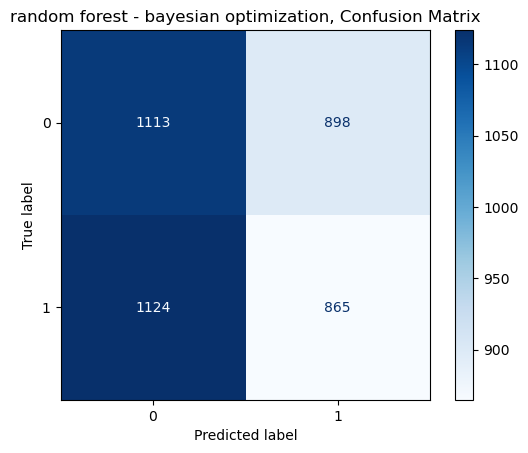

{'f1': 0.49254935973883607, 'precision': 0.4940911514717542, 'recall': 0.49417394876195003}


In [74]:
rf_bopt_metrics = model_performance_metrics("random forest", "bayesian optimization", y_test, y_pred_rf)
print(rf_bopt_metrics)

**CONCLUSION:**

The **Random Forest model** perfomances are not more than "random chance" with **F1 score at 0.49**, which is particulary a **poor result**.  
Besides, the model seems to lean towards predicting "fake" (0) more often than "real" (1).  
The model is failing to learn any meaningful patterns from the data.  
**The Random Forest with TF-IDF features does not seem to be a suitable approach for this classification problem.**

### 2.5.2. Machine learning modeling - Logistic Regression performance metrics:

**METRICS:**

logistic regression, bayesian optimization, F1 score: 0.4900380435378454.
logistic regression, bayesian optimization, Precision score: 0.4909201481338045.
logistic regression, bayesian optimization, Recall score: 0.49099672765101143.

logistic regression, bayesian optimization, Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.54      0.51      2011
           1       0.49      0.44      0.47      1989

    accuracy                           0.49      4000
   macro avg       0.49      0.49      0.49      4000
weighted avg       0.49      0.49      0.49      4000
.



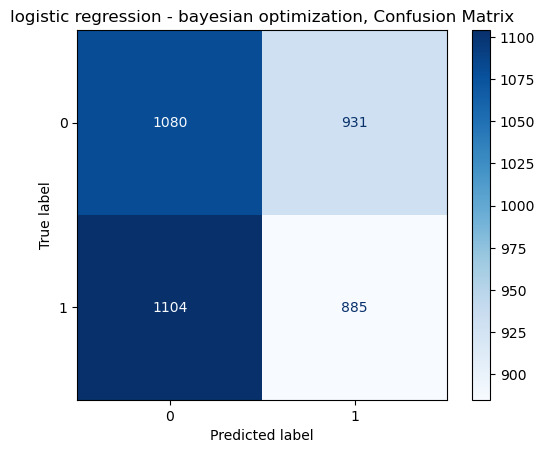

In [75]:
lr_bopt_metrics = model_performance_metrics("logistic regression", "bayesian optimization", y_test, y_pred_lr)

**CONCLUSION:**

The **Logistic Regression model** perfomances are not more than "random chance" with **F1 score at 0.49**, which is particulary a **poor result**.  
Besides, the model shows almost equal counts in all four cells, which proves **it is unable to separate real from fake**.   
The model is failing to learn any meaningful patterns from the data.  
**The Logisitc Regression with TF-IDF features does not seem to be a suitable approach for this classification problem.**

### 2.5.3. Deep learning performance metrics:

**METRICS:**

In [81]:
y_prob = model_dl.predict(X_test_dl, batch_size=256)
y_pred_dl = (y_prob >= 0.5).astype(int).ravel()
print(classification_report(y_test_dl, y_pred_dl, digits=3))
print("F1-macro:", f1_score(y_test_dl, y_pred_dl, average="macro"))
print("ROC-AUC:", roc_auc_score(y_test_dl, y_prob))

16/16 [==============================] - 7s 273ms/step
              precision    recall  f1-score   support

           0      0.503     1.000     0.669      2011
           1      0.000     0.000     0.000      1989

    accuracy                          0.503      4000
   macro avg      0.251     0.500     0.335      4000
weighted avg      0.253     0.503     0.336      4000

F1-macro: 0.3345533189153219
ROC-AUC: 0.49977811828807817


C:\Users\Anaconda\envs\nlpenv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Anaconda\envs\nlpenv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Anaconda\envs\nlpenv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [82]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'auc', 'val_loss', 'val_accuracy', 'val_auc'])


In [83]:
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

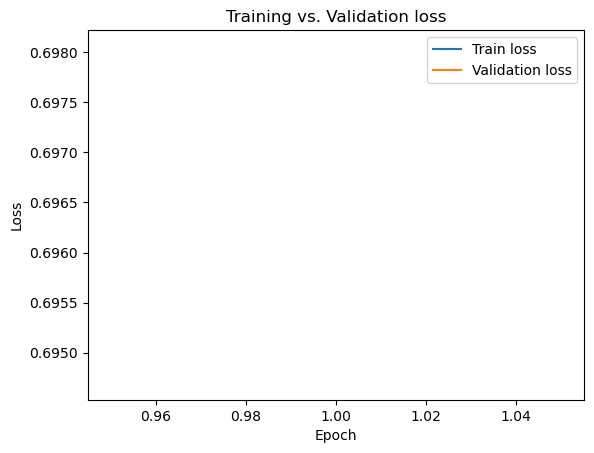

In [84]:
# train and validation loss:
plt.figure()
plt.plot(epochs, hist["loss"], label="Train loss")
plt.plot(epochs, hist["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation loss")
plt.legend()
plt.show()

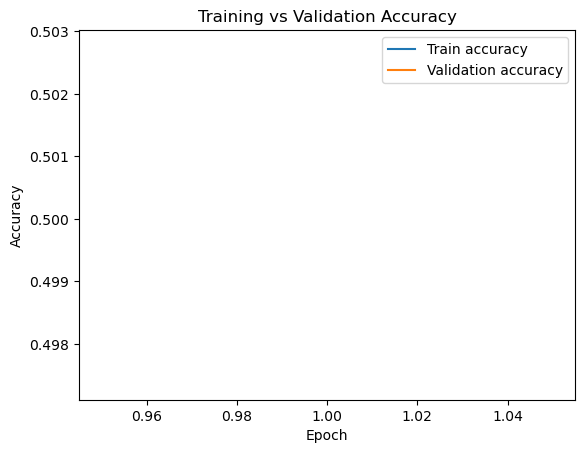

In [85]:
# train and validation accuracy:
plt.figure()
plt.plot(epochs, hist["accuracy"], label="Train accuracy")
plt.plot(epochs, hist["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

**CONCLUSION:**

The model is **severely overfitting** despite all efforts.  
The model is not generalizing and it is memorizing instead.  
Perhaps pretrained embeddings could help (GloVe/fastText, etc.).  
However, fake news detection **might require some richer representation than just word emdeddings**.  
**Contextual embeddings** might help with a **transformer** approach.   

### 2.5.4. Transformer performance metrics:

**METRICS:**

In [92]:
# prints eval_loss + metrics from compute_metrics
print(trainer.evaluate())

pred = trainer.predict(valid_ds)
logits = pred.predictions
probs1 = softmax(logits, axis=-1)[:, 1]
preds  = logits.argmax(axis=-1)

print("AUC:", roc_auc_score(y_test_tr, probs1))
print("F1 :", f1_score(y_test_tr, preds))
print("ACC:", accuracy_score(y_test_tr, preds))
print(classification_report(y_test_tr, preds, digits=3))


***** Running Evaluation *****
  Num examples = 4000
  Batch size = 32



***** Running Prediction *****
  Num examples = 4000
  Batch size = 32


{'eval_loss': 0.694265604019165, 'eval_accuracy': 0.49725, 'eval_f1': 0.6642177325096009, 'eval_auc': 0.5017615532869869, 'eval_runtime': 7.5958, 'eval_samples_per_second': 526.607, 'eval_steps_per_second': 16.456, 'epoch': 6.0}
AUC: 0.5017615532869869
F1 : 0.6642177325096009
ACC: 0.49725
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      2011
           1      0.497     1.000     0.664      1989

    accuracy                          0.497      4000
   macro avg      0.249     0.500     0.332      4000
weighted avg      0.247     0.497     0.330      4000



C:\Users\Anaconda\envs\nlpenv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Anaconda\envs\nlpenv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Anaconda\envs\nlpenv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**CONCLUSION:**

The transformer model **failed to learn meaningful patterns** in the dataset. It collapsed into predicting a single class (class 1), achieving recall of 1.0 for that class but 0.0 for the other, resulting in poor overall accuracy (50%) and AUC (0.5, equivalent to random guessing). This indicates that the model is not generalizing and is essentially performing at chance level. This might be due to the **poor quality of the dataset which cannot provide with strong signal.**  

### 2.5.5. Model selection & overall conclusion:

None of the proposed model could give a satisfying calssification result.  
After deeper analysis of the dataset, indeed, **the text is completely non sense with no structure and no particular signal**.  
**The overall conclusion might be that the KAGGLE database might NOT BE RELIABLE SOURCE in providing reliable datasets to be used in MAchinle Learning.**